In [42]:
import gymnasium as gym
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

obs:
1. Cart Position — horizontal position of the cart
2. Cart Velocity — speed of the cart
3. Pole Angle — angle of the pole from vertical (radians)
4. Pole Angular Velocity — rotational speed of the pole

In [43]:
env = gym.make("CartPole-v1")
obs, info = env.reset()
obs,info

(array([-0.0288793 ,  0.02296931,  0.02258613,  0.04032357], dtype=float32),
 {})

In [44]:
print(env.action_space)
print(env.observation_space)

Discrete(2)
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


In [45]:
action=1
obs, reward, terminated, truncated, info = env.step(action)
obs, reward, terminated, truncated, info

(array([-0.02841991,  0.21776022,  0.0233926 , -0.24514851], dtype=float32),
 1.0,
 False,
 False,
 {})

In [46]:
def basic_policy (obs):
    angle=obs[2]
    return 0 if angle < 0 else 1

In [47]:
totals = []
t_obs=[]

for episode in range(500):
    episode_rewards = 0

    obs, info = env.reset()
    
    for step in range(200):
        
        action = basic_policy(obs)

        obs, reward, terminated, truncated, info = env.step(action)

        t_obs.append(np.append(obs,action))
                
        done = terminated or truncated

        episode_rewards += reward


        if done:
            break

    totals.append(episode_rewards)
    
pd.DataFrame(t_obs,columns=["Cart Position","Cart Velocity","Pole Angle","Pole Angular Velocity","Reward"]).to_csv("../rl-catpole-neuron-network-policy-maximum-probability/data.csv", index=False)
pd.DataFrame(t_obs,columns=["Cart Position","Cart Velocity","Pole Angle","Pole Angular Velocity","Action"]).to_csv("../rl-catpole-neuron-network-policy-multinominal-sampling/data.csv", index=False)

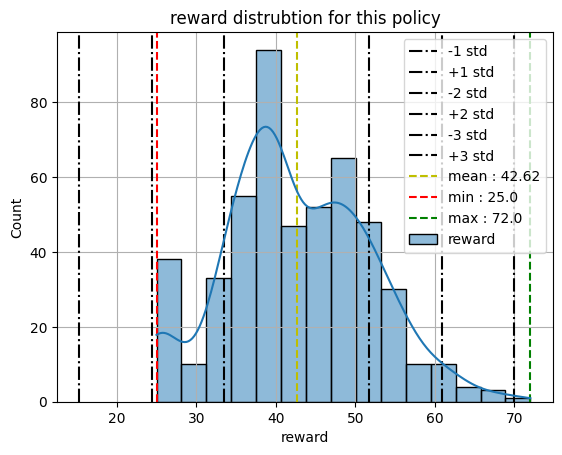

In [48]:
for i in range(1,4):
    plt.axvline(np.mean(totals)-np.std(totals)*i,linestyle="-.",color="black",label=f"-{i} std")
    plt.axvline(np.mean(totals)+np.std(totals)*i,linestyle="-.",color="black",label=f"+{i} std")


plt.axvline(np.mean(totals),linestyle="--",color="y",label=f"mean : {np.mean(totals)}")
plt.axvline(np.min(totals),linestyle="--",color="r",label=f"min : {np.min(totals)}")
plt.axvline(np.max(totals),linestyle="--",color="g",label=f"max : {np.max(totals)}")

plt.title("reward distrubtion for this policy")
sns.histplot(totals,kde=True,label="reward")
plt.xlabel("reward")
plt.legend()
plt.grid()
plt.show()



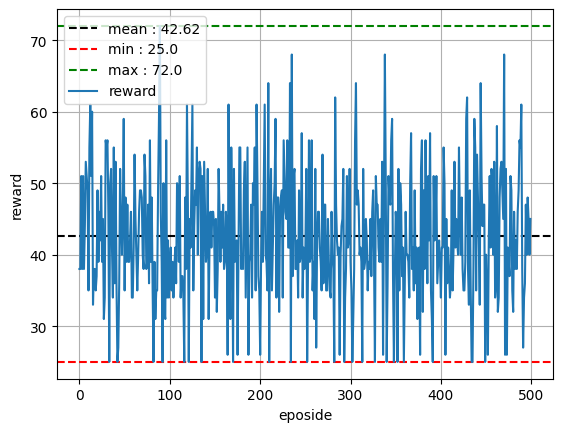

In [49]:
plt.axhline(np.mean(totals),linestyle="--",color="black",label=f"mean : {np.mean(totals)}")
plt.axhline(np.min(totals),linestyle="--",color="r",label=f"min : {np.min(totals)}")
plt.axhline(np.max(totals),linestyle="--",color="g",label=f"max : {np.max(totals)}")

sns.lineplot(totals,label="reward")
plt.xlabel("eposide")
plt.ylabel("reward")
plt.legend()
plt.grid()
plt.show()

In [50]:
i = 0

while True:
    if i >= len(totals):
        break

    if totals[i] == np.max(totals):
        print(f"At the episode {i} reache maximum reward {totals[i]}")
        break

    i += 1

At the episode 89 reache maximum reward 72.0
